Welcome to our Operations Research project 🚀

Choose an option :
1. Compute Max Flow with Ford-Fulkerson
2. Compute Max Flow with Push-Relabel
3. Compute Min-Cost Flow
4. Analyze algorithmic complexity


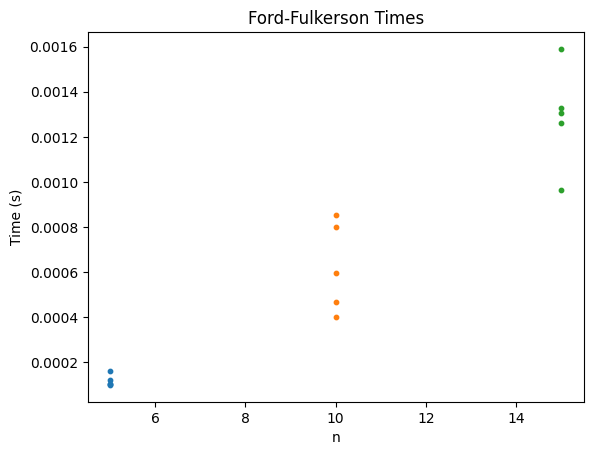

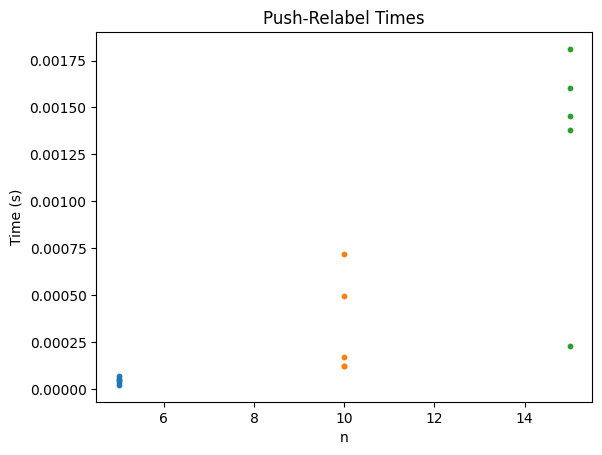

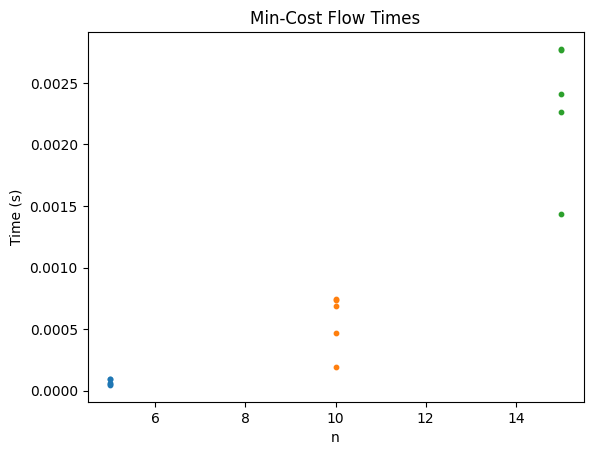

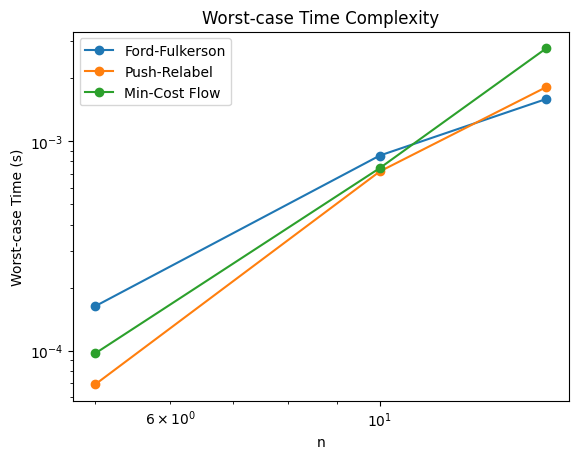

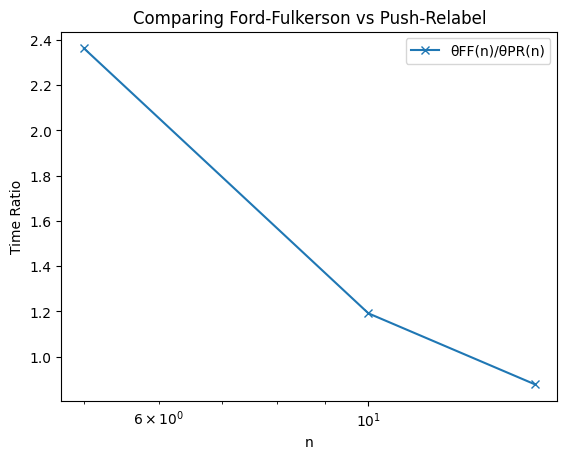


Initial residual graph:

Residual Graph
     0      0      0      0     86
    95      0     43      5     99
     2      0      0      0     28
    75     94     37      0      0
     0     90     20      0      0

Iteration 1:
Breadth-first search:
Π(4) = 0
Improving path found: 0 → 4
Flow in path: 86
Residual graph after this iteration:

Residual Graph
     0      0      0      0      0
    95      0     43      5     99
     2      0      0      0     28
    75     94     37      0      0
    86     90     20      0      0

Final residual graph:

Final Residual Graph
     0      0      0      0      0
    95      0     43      5     99
     2      0      0      0     28
    75     94     37      0      0
    86     90     20      0      0
Max Flow = 86

Initial residual graph:

Residual Graph
     0      0      0      0     86
    95      0     43      5     99
     2      0      0      0     28
    75     94     37      0      0
     0     90     20      0      0

Iteration 1:
Br

In [4]:
# Projet SM602I - Recherche Opérationnelle
# Implémentation des algorithmes : Ford-Fulkerson, Push-Relabel, Min-Cost Flow

import time
import random
from collections import deque, defaultdict
import matplotlib.pyplot as plt

#############################################
# FONCTIONS DE BASE : LECTURE ET AFFICHAGE
#############################################

def read_capacity_matrix(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()
        n = int(lines[0])
        matrix = [list(map(int, line.strip().split())) for line in lines[1:n+1]]
    return n, matrix

def read_capacity_cost_matrix(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()
        n = int(lines[0])
        capacity = [list(map(int, lines[i+1].strip().split())) for i in range(n)]
        cost = [list(map(int, lines[i+1+n].strip().split())) for i in range(n)]
    return n, capacity, cost

def display_matrix(matrix, title):
    print(f"\n{title}")
    for row in matrix:
        print(" ".join(f"{val:6}" for val in row))


#############################################
# ALGORITHME FORD-FULKERSON AVEC BFS
#############################################

def bfs(rGraph, s, t, parent):
    visited = [False] * len(rGraph)
    queue = deque([s])
    visited[s] = True
    while queue:
        u = queue.popleft()
        for v, cap in enumerate(rGraph[u]):
            if not visited[v] and cap > 0:
                queue.append(v)
                visited[v] = True
                parent[v] = u
    return visited[t]

def ford_fulkerson(capacity, s, t):
    n = len(capacity)
    rGraph = [row[:] for row in capacity]
    parent = [-1] * n
    max_flow = 0
    iteration = 1

    def reconstruct_path(parent, s, t):
        path = []
        v = t
        while v != s:
            path.append(v)
            v = parent[v]
        path.append(s)
        path.reverse()
        return path

    print("\nInitial residual graph:")
    display_matrix(rGraph, "Residual Graph")

    while bfs(rGraph, s, t, parent):
        path_flow = float('inf')
        v = t
        while v != s:
            u = parent[v]
            path_flow = min(path_flow, rGraph[u][v])
            v = parent[v]

        path = reconstruct_path(parent, s, t)
        print(f"\nIteration {iteration}:")
        print("Breadth-first search:")
        for i in range(1, len(path)):
            print(f"Π({path[i]}) = {path[i-1]}")
        print("Improving path found:", " → ".join(map(str, path)))
        print("Flow in path:", path_flow)

        v = t
        while v != s:
            u = parent[v]
            rGraph[u][v] -= path_flow
            rGraph[v][u] += path_flow
            v = parent[v]

        print("Residual graph after this iteration:")
        display_matrix(rGraph, "Residual Graph")

        max_flow += path_flow
        iteration += 1

    print("\nFinal residual graph:")
    display_matrix(rGraph, "Final Residual Graph")
    print("Max Flow =", max_flow)
    return max_flow


#############################################
# ALGORITHME PUSH-RELABEL
#############################################

def push_relabel(capacity, s, t):
    n = len(capacity)
    flow = [[0] * n for _ in range(n)]
    height = [0] * n
    excess = [0] * n
    height[s] = n

    for v in range(n):
        flow[s][v] = capacity[s][v]
        flow[v][s] = -flow[s][v]
        excess[v] = capacity[s][v]

    def push(u, v):
        send = min(excess[u], capacity[u][v] - flow[u][v])
        flow[u][v] += send
        flow[v][u] -= send
        excess[u] -= send
        excess[v] += send

    def relabel(u):
        min_height = float('inf')
        for v in range(n):
            if capacity[u][v] - flow[u][v] > 0:
                min_height = min(min_height, height[v])
        if min_height < float('inf'):
            height[u] = min_height + 1

    def discharge(u):
        while excess[u] > 0:
            for v in range(n):
                if capacity[u][v] - flow[u][v] > 0 and height[u] == height[v] + 1:
                    push(u, v)
                    if excess[u] == 0:
                        break
            else:
                relabel(u)

    active = [i for i in range(n) if i != s and i != t]
    p = 0
    while p < len(active):
        u = active[p]
        old_height = height[u]
        discharge(u)
        if height[u] > old_height:
            active.insert(0, active.pop(p))
            p = 0
        else:
            p += 1

    return sum(flow[s])

#############################################
# ALGORITHME MIN-COST FLOW (BELLMAN-FORD)
#############################################

def bellman_ford(n, capacity, cost, s):
    dist = [float('inf')] * n
    dist[s] = 0
    print("\nTable from Bellman's algorithm:")
    print(f"Iteration 0: {dist}")
    for it in range(1, n):
        updated = dist[:]
        for u in range(n):
            for v in range(n):
                if capacity[u][v] > 0 and dist[u] + cost[u][v] < updated[v]:
                    updated[v] = dist[u] + cost[u][v]
        dist = updated[:]
        print(f"Iteration {it}: {dist}")
    return dist

def min_cost_flow(capacity, cost, s, t, target_flow):
    n = len(capacity)
    flow = 0
    total_cost = 0
    residual = [capacity[i][:] for i in range(n)]

    while flow < target_flow:
        dist = bellman_ford(n, residual, cost, s)
        path = [-1]*n
        for u in range(n):
            for v in range(n):
                if residual[u][v] > 0 and dist[v] == dist[u] + cost[u][v]:
                    path[v] = u
        if path[t] == -1:
            break

        increment = target_flow - flow
        v = t
        while v != s:
            u = path[v]
            increment = min(increment, residual[u][v])
            v = u

        v = t
        while v != s:
            u = path[v]
            residual[u][v] -= increment
            residual[v][u] += increment
            total_cost += increment * cost[u][v]
            v = u

        flow += increment

    return total_cost

#############################################
# ANALYSE DE COMPLEXITÉ
#############################################

def generate_random_graph(n):
    C = [[0]*n for _ in range(n)]
    D = [[0]*n for _ in range(n)]
    E = (n*n)//2
    edges = random.sample([(i, j) for i in range(n) for j in range(n) if i != j], E)
    for i, j in edges:
        C[i][j] = random.randint(1, 100)
        D[i][j] = random.randint(1, 100)
    return C, D

def measure_execution_time(n_values, repetitions=100):
    times_ff, times_pr, times_min = {}, {}, {}
    for n in n_values:
        ff_list, pr_list, min_list = [], [], []
        for _ in range(repetitions):
            C, D = generate_random_graph(n)
            s, t = 0, n-1
            start = time.process_time()
            ford_fulkerson(C, s, t)
            ff_list.append(time.process_time() - start)

            start = time.process_time()
            push_relabel(C, s, t)
            pr_list.append(time.process_time() - start)

            flow_value = ford_fulkerson(C, s, t) // 2
            start = time.process_time()
            min_cost_flow(C, D, s, t, flow_value)
            min_list.append(time.process_time() - start)

        times_ff[n] = ff_list
        times_pr[n] = pr_list
        times_min[n] = min_list
    return times_ff, times_pr, times_min

def plot_point_clouds(times_dict, title):
    for n, times in times_dict.items():
        plt.scatter([n]*len(times), times, s=10)
    plt.title(title)
    plt.xlabel("n")
    plt.ylabel("Time (s)")
    plt.show()

def plot_worst_case(times_dict, label):
    max_times = sorted([(n, max(times)) for n, times in times_dict.items()])
    ns, worsts = zip(*max_times)
    plt.plot(ns, worsts, marker='o', label=label)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("n")
    plt.ylabel("Worst-case Time (s)")
    plt.legend()
    plt.title("Worst-case Time Complexity")

def plot_ff_vs_pr(times_ff, times_pr):
    ns = sorted(times_ff.keys())
    ratios = [max(times_ff[n]) / max(times_pr[n]) for n in ns]
    plt.plot(ns, ratios, marker='x', label="θFF(n)/θPR(n)")
    plt.xscale("log")
    plt.xlabel("n")
    plt.ylabel("Time Ratio")
    plt.title("Comparing Ford-Fulkerson vs Push-Relabel")
    plt.legend()

def guess_complexity(ns, times):
    import numpy as np
    from scipy.optimize import curve_fit

    def models():
        return {
            "O(log n)": lambda n, a, b: a * np.log(n) + b,
            "O(n)": lambda n, a, b: a * n + b,
            "O(n log n)": lambda n, a, b: a * n * np.log(n) + b,
            "O(n^2)": lambda n, a, b: a * n**2 + b,
            "O(n^3)": lambda n, a, b: a * n**3 + b,
        }

    errors = {}
    for name, model in models().items():
        try:
            popt, _ = curve_fit(model, ns, times)
            fit = model(np.array(ns), *popt)
            error = np.mean((np.array(times) - fit) ** 2)
            errors[name] = error
        except:
            continue

    best_fit = min(errors, key=errors.get)
    return best_fit



import sys
import os
from io import StringIO

def save_trace_to_file(filename, output):
    with open(filename, 'w') as f:
        f.write(output)



def main():
    print("Welcome to our Operations Research project 🚀")

    group = input("Enter your group (e.g., B): ").strip().upper()
    team = input("Enter your team number (e.g., 4): ").strip()

    while True:
        print("\nChoose an option :")
        print("1. Compute Max Flow with Ford-Fulkerson")
        print("2. Compute Max Flow with Push-Relabel")
        print("3. Compute Min-Cost Flow")
        print("4. Analyze algorithmic complexity")
        choice = input("Your choice (1, 2, 3 or 4) : ")

        # Capture output
        buffer = StringIO()
        original_stdout = sys.stdout
        sys.stdout = buffer

        if choice in ["1", "2"]:
            try:
                num = int(input("Enter the number of the graph (1 to 5) : "))
                while num < 1 or num > 5:
                    num = int(input("Choose only a number from 1 to 5 : "))
                filename = f"proposal{num}.txt"
                n, capacity = read_capacity_matrix(filename)
                display_matrix(capacity, "Capacity Matrix")

                if choice == "1":
                    result = ford_fulkerson(capacity, 0, n - 1)
                    print("\nMax Flow (Ford-Fulkerson) :", result)
                    trace_filename = f"{group}{team}-trace{num}-FF.txt"
                else:
                    result = push_relabel(capacity, 0, n - 1)
                    print("\nMax Flow (Push-Relabel) :", result)
                    trace_filename = f"{group}{team}-trace{num}-PR.txt"

            except FileNotFoundError:
                print("File not found. Verify the number.")
                trace_filename = None
            except ValueError:
                print("Invalid input. Please enter an integer.")
                trace_filename = None

        elif choice == "3":
            try:
                num = int(input("Enter the number of the graph (6 to 10) : "))
                while num < 6 or num > 10:
                    num = int(input("Choose only a number from 6 to 10 : "))
                filename = f"proposal{num}.txt"
                n, capacity, cost = read_capacity_cost_matrix(filename)
                display_matrix(capacity, "Capacity Matrix")
                display_matrix(cost, "Cost Matrix")
                flow_value = ford_fulkerson(capacity, 0, n - 1) // 2
                result = min_cost_flow(capacity, cost, 0, n - 1, flow_value)
                print("\nMin-Cost Flow for a flow of", flow_value, ":", result)
                trace_filename = f"{group}{team}-trace{num}-MIN.txt"

            except FileNotFoundError:
                print("File not found. Verify the number.")
                trace_filename = None
            except ValueError:
                print("Invalid input. Please enter an integer.")
                trace_filename = None

        elif choice == "4":
            try:
                n_values = [5, 10, 15]  # Tu peux modifier selon ton test
                times_ff, times_pr, times_min = measure_execution_time(n_values, repetitions=5)

                sys.stdout = original_stdout  # Affiche les graphes hors capture
                plot_point_clouds(times_ff, "Ford-Fulkerson Times")
                plot_point_clouds(times_pr, "Push-Relabel Times")
                plot_point_clouds(times_min, "Min-Cost Flow Times")

                plot_worst_case(times_ff, "Ford-Fulkerson")
                plot_worst_case(times_pr, "Push-Relabel")
                plot_worst_case(times_min, "Min-Cost Flow")
                plt.show()

                plot_ff_vs_pr(times_ff, times_pr)
                plt.show()

                trace_filename = None

            except Exception as e:
                print("Error during complexity analysis:", str(e))
                trace_filename = None

        else:
            print("Invalid choice. Please enter 1, 2, 3 or 4.")
            trace_filename = None

        # Stop capturing and save trace
        sys.stdout = original_stdout
        output = buffer.getvalue()
        print(output)  # Also show in console

        if trace_filename:
            save_trace_to_file(trace_filename, output)
            print(f"Trace saved to {trace_filename}")

        again = input("\nDo you want to solve another problem? (y/n): ")
        if again.lower() != 'y':
            print("Goodbye! 👋")
            break



if __name__ == "__main__":
    main()
